Marketing A/B Testing Project

In [5]:
# import libraries
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load and inspect data
df = pd.read_csv('/content/marketing_AB.csv')

# Display first rows
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [7]:
# Remove unused columns
df.drop(columns=['Unnamed: 0', 'user id'], inplace=True)

# Display first rows
df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [8]:
# Basic EDA
print("Shape:", df.shape)
print(df.info())

# Summary stats for numeric columns
df.describe().T

Shape: (588101, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 18.5+ MB
None


,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


In [9]:
# Unique values
print("Test group:", df['test group'].unique())
print("Converted:", df['converted'].unique())
print("Most ads day:", df['most ads day'].unique())

Test group: ['ad' 'psa']
Converted: [False  True]
Most ads day: ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']


In [10]:
# data processing
df['converted']

,converted
0,False
1,False
2,False
3,False
4,False
...,...
588096,False
588097,False
588098,False
588099,False


In [11]:
# Convert boolean to integer for numerical tests
df['converted'] = df['converted'].astype(int)

df.dtypes

,0
test group,object
converted,int64
total ads,int64
most ads day,object
most ads hour,int64


In [12]:
df['converted']

,converted
0,0
1,0
2,0
3,0
4,0
...,...
588096,0
588097,0
588098,0
588099,0


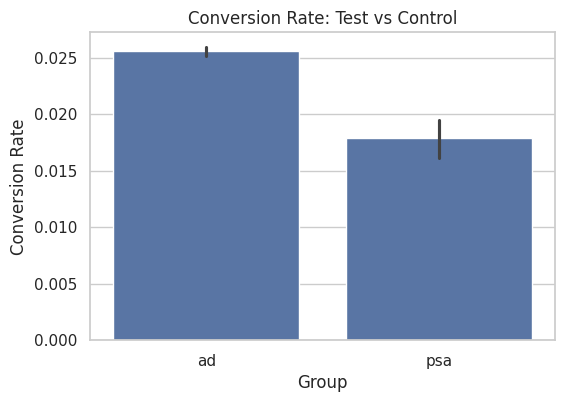

In [13]:
# visualization
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='test group', y='converted')
plt.title("Conversion Rate: Test vs Control")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

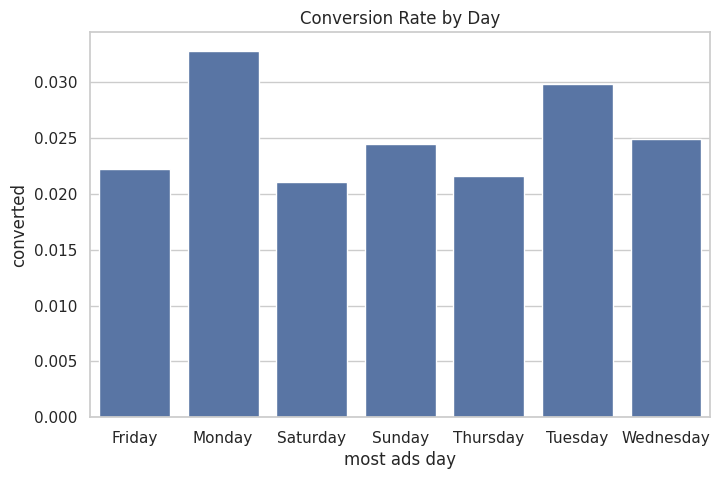

In [14]:
day_rate = df.groupby('most ads day')['converted'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=day_rate, x='most ads day', y='converted')
plt.title("Conversion Rate by Day")
plt.show()

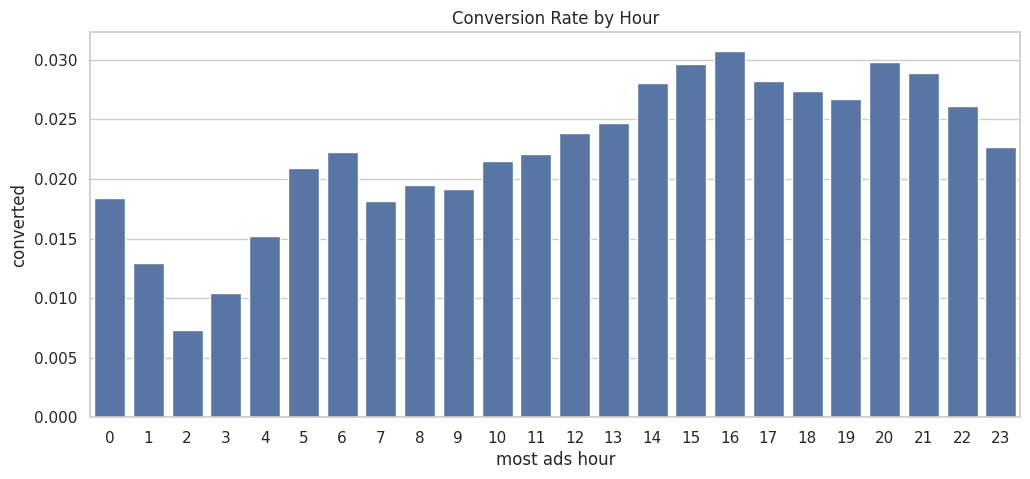

In [15]:
hour_rate = df.groupby('most ads hour')['converted'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=hour_rate, x='most ads hour', y='converted')
plt.title("Conversion Rate by Hour")
plt.show()

In [16]:
#statistical testing
# a/b test - comparing conversion rates
control_group = df[df['test group'] == 'psa']
test_group = df[df['test group'] == 'ad']

control_conv = control_group['converted']
test_conv = test_group['converted']

t_stat , p_val = stats.ttest_ind(test_conv , control_conv)

print("t-statistic:", t_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Result: Reject H0 -> Significant difference in conversion rates")
else:
    print("Result: Fail to reject h0 -> No significant difference")

t-statistic: 7.37040597428566
P-value: 1.7033052627831264e-13
Result: Reject H0 -> Significant difference in conversion rates


In [18]:
# anova
# does day of most ads affect conversion?

anova_day = stats.f_oneway(*[
    df[df['most ads day'] == day]['converted']
    for day in df['most ads day'].unique()
])

print("ANOVA — Most Ads Day")
print("F-statistic:", anova_day.statistic)
print("P-value:", anova_day.pvalue)

if anova_day.pvalue < 0.05:
    print("Result: Reject H0 -> Day significantly affects conversion.")
else:
    print("Result: Fail to reject H0 -> No effect of day.")

ANOVA — Most Ads Day
F-statistic: 68.38818386896018
P-value: 1.803200765653882e-85
Result: Reject H0 -> Day significantly affects conversion.


In [19]:
# anova
# does hour with most ads affect conversion?

anova_hour = stats.f_oneway(*[
    df[df['most ads hour'] == hr]['converted']
    for hr in sorted(df['most ads hour'].unique())
])

print("ANOVA — Most Ads Hour")
print("F-statistic:", anova_hour.statistic)
print("P-value:", anova_hour.pvalue)

if anova_hour.pvalue < 0.05:
    print("Result: Reject H0 -> Hour significantly affects conversion.")
else:
    print("Result: Fail to reject H0.")

ANOVA — Most Ads Hour
F-statistic: 18.74203731296957
P-value: 7.482025335314286e-77
Result: Reject H0 -> Hour significantly affects conversion.


In [ ]:
# The treatment group of ads has a significantly higher conversion rate
# The day & hour when users saw the most ads significantly affect conversions
# Marketing team should optimize ad frequency and place ads in peak conversion hours